# BUSINESS INTELLIGENCE: REPORTE AL CEO (SQL + VISUALIZACION)

In [4]:
## clonar o actualizar repositorio github en colab

from pathlib import Path
import os

ruta_proyecto = Path("/content/etl-python-analisis-food-delivery")

# Si el repositorio no existe, lo clona
if not ruta_proyecto.exists():
    %cd /content
    !git clone https://github.com/dannyturpo-data/etl-python-analisis-food-delivery.git

# Si ya existe, actualiza cambios
else:
    %cd /content/etl-python-analisis-food-delivery
    !git pull origin main

/content
Cloning into 'etl-python-analisis-food-delivery'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 103 (delta 6), reused 13 (delta 3), pack-reused 84 (from 4)
Receiving objects: 100% (103/103), 45.45 MiB | 18.41 MiB/s, done.
Resolving deltas: 100% (35/35), done.
Updating files: 100% (22/22), done.


In [5]:
## configuracion

import sys

if str(ruta_proyecto) not in sys.path:
    sys.path.append(str(ruta_proyecto))

## importar librerias

import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy import text

## CONECTANDO A SQLite

In [6]:
## conectando a la base de datos
engine = create_engine(
    "sqlite:////content/etl-python-analisis-food-delivery/data/base_datos/delivery_insights.db"
)

In [10]:
## abriendo conexion explicita
conn = engine.connect()

In [8]:
## consultando tabla
consulta = pd.read_sql(
    "SELECT * FROM master_food_data LIMIT 5",
    con=engine # la bd se conecta a pd para realizar la operacion.
)
consulta

,restaurant_id,position,name_restaurant,score,ratings,category_restaurant,price_range,full_address,lat,lng,calle,ciudad,estado_zip,category_menu,name_menu,description,price
0,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",picked for you,spring roll,"three rolls. shrimps, sliced pork, vermicelli ...",6.99
1,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",picked for you,egg roll,"pork, carrot, bean thread noodles, and are wra...",6.50
2,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",picked for you,grilled pork,foot long.,9.50
3,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",picked for you,house special,"rice noodle with steak, rare, flank, brisket, ...",10.95
4,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",picked for you,rice noodle with rare steak,sin descripcion,10.95


## BUSINESS INTELLIGENCE

### 1. PENETRACION GEOGRAFICA
¿Cuáles son las 5 ciudades (ciudad) con la mayor
cantidad de restaurantes consolidados (los que quedaron en nuestra base)?
Gráfico sugerido: Gráfico de barras horizontal ordenado de mayor a menor.

In [32]:
query = """
SELECT
    ciudad,
    COUNT(DISTINCT restaurant_id) AS total_restaurantes
FROM master_food_data
GROUP BY ciudad
ORDER BY total_restaurantes DESC
LIMIT 5;
"""

df_ciudades = pd.read_sql(text(query), conn)

df_ciudades

,ciudad,total_restaurantes
0,Milwaukee,123
1,Seattle,119
2,Lynnwood,42
3,Everett,32
4,Bellevue,30


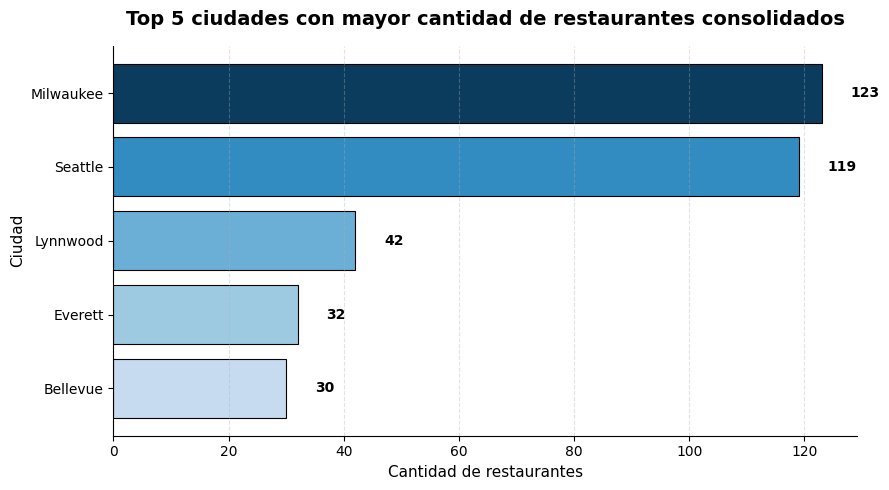

In [33]:
# Ordenar de mayor a menor
df_ciudades = df_ciudades.sort_values(
    by="total_restaurantes",
    ascending=False
)

plt.figure(figsize=(9,5))

colores = [
    "#0B3C5D",
    "#328CC1",
    "#6BAED6",
    "#9ECAE1",
    "#C6DBEF"
]

barras = plt.barh(
    df_ciudades["ciudad"],
    df_ciudades["total_restaurantes"],
    color=colores,
    edgecolor="black",
    linewidth=0.8
)

# Ciudad con mayor cantidad arriba
plt.gca().invert_yaxis()


# Etiquetas con valores
for barra in barras:
    ancho = barra.get_width()

    plt.text(
        ancho + 5,
        barra.get_y() + barra.get_height()/2,
        f"{int(ancho):,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )


plt.title(
    "Top 5 ciudades con mayor cantidad de restaurantes consolidados",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Cantidad de restaurantes",
    fontsize=11
)

plt.ylabel(
    "Ciudad",
    fontsize=11
)


plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.show()

El análisis evidencia una concentración geográfica del mercado, Milwaukee y Seattel reúnen la mayor cantidad de restaurantes consolidados. Esto permite identificar las zonas con mayor presencia y orientar decisiones estratégicas basadas en la densidad actual de oferta gastronómica, expasión de servicios.

### 2. ANALISIS DE OPORTUNIDAD DE PRECIO

El CEO cree que todos los restaurantes en
el mercado son caros. Usando los datos, muestre la distribución de la columna
rango_de_precios a nivel general (¿Cuántos hay en "Económico", "Caro", etc.?).

In [29]:
query = """
SELECT
    price_range,
    COUNT(*) AS total_restaurantes
FROM (

    SELECT DISTINCT
        restaurant_id,
        price_range
    FROM master_food_data

)

GROUP BY price_range

ORDER BY CASE price_range
    WHEN 'Económico' THEN 1
    WHEN 'Moderadamente caro' THEN 2
    WHEN 'Caro' THEN 3
    WHEN 'Muy caro' THEN 4
    WHEN 'No Registra' THEN 5
END;
"""

df_rango_precios = pd.read_sql(text(query), conn)

df_rango_precios

,price_range,total_restaurantes
0,Económico,449
1,Moderadamente caro,157
2,Caro,4
3,No Registra,59


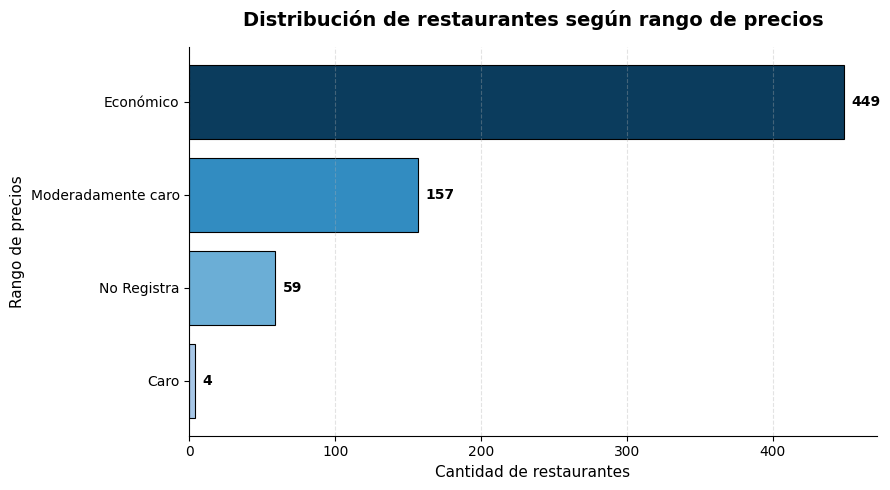

In [31]:
# Ordenar por cantidad de restaurantes
df_rango_precios = df_rango_precios.sort_values(
    by="total_restaurantes",
    ascending=False
)

# Paleta de colores
colores = [
    "#0B3C5D",
    "#328CC1",
    "#6BAED6",
    "#A7C7E7",
    "#D9D9D9"
]

plt.figure(figsize=(9, 5))

barras = plt.barh(
    df_rango_precios["price_range"],
    df_rango_precios["total_restaurantes"],
    color=colores,
    edgecolor="black",
    linewidth=0.8
)

# Mostrar la categoría con mayor cantidad arriba
plt.gca().invert_yaxis()

# Etiquetas de los valores
for barra in barras:
    ancho = barra.get_width()

    plt.text(
        ancho + 5,
        barra.get_y() + barra.get_height()/2,
        f"{int(ancho):,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Distribución de restaurantes según rango de precios",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Cantidad de restaurantes", fontsize=11)
plt.ylabel("Rango de precios", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

La distribución de restaurantes por rango de precios muestra que la mayor parte de la oferta se concentra en las categorías Económico y Moderadamente caro, mientras que los restaurantes clasificados como Caro y No Registra representan una proporción menor del mercado. La categoria Muy Caro no cuenta con registros.

Los datos no respaldan la percepción inicial del CEO de que la mayoría de los restaurantes del mercado son caros. Por el contrario, la oferta se concentra principalmente en establecimientos económicos y moderadamente caros, lo que representa una oportunidad para orientar estrategias comerciales hacia segmentos de precios accesibles sin sacrificar cobertura del mercado.

### 3. ESTRATEGIA DE MENUS POR CIUDAD

Para las 3 ciudades más populares obtenidas
en la pregunta 1, calcule el precio promedio de los platos en el menú. ¿En
qué ciudad es más caro comer en promedio?

Las 3 ciudades mas populares son Milwaukee, Seattle y Lynnwood.

In [13]:
query = """
SELECT
    ciudad,
    ROUND(AVG(price),2) AS precio_promedio
FROM master_food_data
WHERE ciudad IN (

    SELECT ciudad
    FROM (
        SELECT
            ciudad,
            COUNT(DISTINCT restaurant_id) AS total_restaurantes
        FROM master_food_data
        GROUP BY ciudad
        ORDER BY total_restaurantes DESC
        LIMIT 3
    )

)
GROUP BY ciudad
ORDER BY precio_promedio DESC;
"""

df_promedio_menu = pd.read_sql(text(query), conn)

df_promedio_menu

,ciudad,precio_promedio
0,Seattle,11.97
1,Lynnwood,10.76
2,Milwaukee,9.53


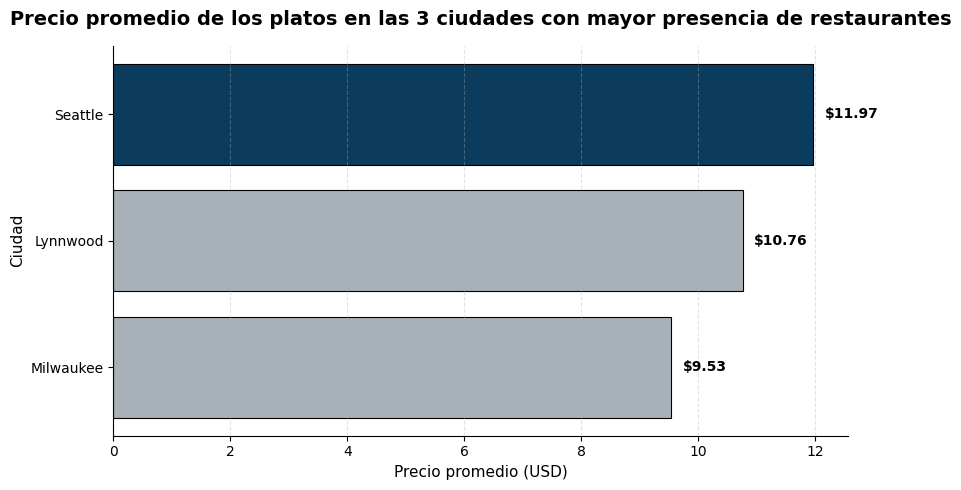

In [21]:
plt.figure(figsize=(9, 5))

# Resaltar la ciudad con mayor precio promedio
colores = ["#0B3C5D", "#A7B1B7", "#A7B1B7"]

barras = plt.barh(
    df_promedio_menu["ciudad"],
    df_promedio_menu["precio_promedio"],
    color=colores,
    edgecolor="black",
    linewidth=0.8
)

# Mostrar la ciudad con mayor precio arriba
plt.gca().invert_yaxis()

# Etiquetas de los valores
for barra in barras:
    ancho = barra.get_width()
    plt.text(
        ancho + 0.2,
        barra.get_y() + barra.get_height() / 2,
        f"${ancho:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Precio promedio de los platos en las 3 ciudades con mayor presencia de restaurantes",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Precio promedio (USD)", fontsize=11)
plt.ylabel("Ciudad", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Entre las tres ciudades con mayor presencia de restaurantes consolidados, Seattle presenta el mayor precio promedio de los platos del menú, seguida de Lynnwood y Milwaukee. Esto sugiere que, dentro de los mercados con mayor concentración de restaurantes, Seattle representa el segmento con el ticket promedio más elevado.

### 4. Correlación Precio-Calidad:

¿Un restaurante más
caro garantiza una mejor experiencia para el usuario? Escriba un query que
calcule el puntaje (score) promedio agrupado por rango_de_precios. Utilice un
gráfico de líneas o de barras para demostrar visualmente al CEO si la calidad
sube a medida que aumenta la categoría de precio.

In [22]:
query = """
SELECT
    restaurant_id, price_range, score, name_menu
FROM
    master_food_data;
"""

df_consulta = pd.read_sql(text(query), conn)

df_consulta

,restaurant_id,price_range,score,name_menu
0,1739,Económico,4.4,spring roll
1,1739,Económico,4.4,egg roll
2,1739,Económico,4.4,grilled pork
3,1739,Económico,4.4,house special
4,1739,Económico,4.4,rice noodle with rare steak
...,...,...,...,...
62978,10076,Económico,4.6,stubborn soda
62979,10076,Económico,4.6,pure leaf tea
62980,10076,Económico,4.6,cookie
62981,10076,Económico,4.6,brownie


Tener en cuenta que score pertenece al restaurante no al plato. Tambien como restaurante_id repite varias veces algunos id, este identifica al restaurante. Entonces un restaurante aportaria varias veces al promedio, porque tiene varios platos, esto introduciria un sesgo en el analisis, los restaurantes con mas platos pesarian mas en el calculo.

Debemos quedarnos con un registro por restaurante y luego calcular el promedio.

In [25]:
query = """
SELECT
    price_range,
    ROUND(AVG(score),2) AS score_promedio
FROM (

    SELECT DISTINCT
        restaurant_id,
        price_range,
        score
    FROM master_food_data

)

GROUP BY price_range

ORDER BY CASE price_range
    WHEN 'Económico' THEN 1
    WHEN 'Moderadamente caro' THEN 2
    WHEN 'Caro' THEN 3
    WHEN 'Muy caro' THEN 4
    WHEN 'No Registra' THEN 5
END;
"""

df_score_restaurant = pd.read_sql(text(query), conn)

df_score_restaurant

,price_range,score_promedio
0,Económico,4.62
1,Moderadamente caro,4.64
2,Caro,4.45
3,No Registra,4.66


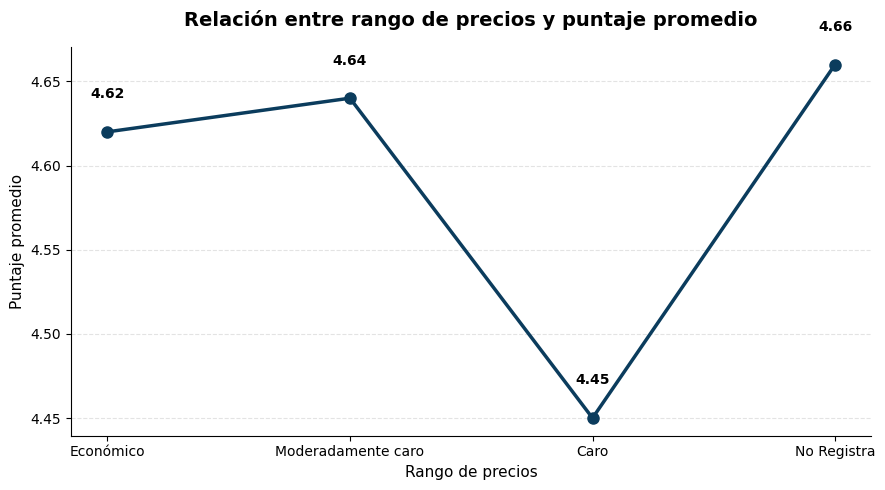

In [27]:
plt.figure(figsize=(9,5))

plt.plot(
    df_score_restaurant["price_range"],
    df_score_restaurant["score_promedio"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#0B3C5D"
)

# Mostrar el valor de cada punto
for x, y in zip(df_score_restaurant["price_range"], df_score_restaurant["score_promedio"]):
    plt.text(
        x,
        y + 0.02,
        f"{y:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Relación entre rango de precios y puntaje promedio",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Rango de precios", fontsize=11)
plt.ylabel("Puntaje promedio", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

¿Un restaurante más
caro garantiza una mejor experiencia para el usuario? Los datos contradicen esta percepcion inicial.

In [28]:
df_score_restaurant

,price_range,score_promedio
0,Económico,4.62
1,Moderadamente caro,4.64
2,Caro,4.45
3,No Registra,4.66


Se aprecia que:

* Los restaurantes económicos tienen una calificación muy alta (4.62).
* Los moderadamente caros presentan un ligero incremento (4.64).
* Los restaurantes caros tienen el puntaje promedio más bajo (4.45).
* La categoría "No Registra" tiene la puntuación más alta (4.66), aunque debe interpretarse con cautela porque no representa un nivel de precio definido.

Por lo tanto, no existe una tendencia creciente en la calidad conforme aumenta el rango de precios.

Con base en los datos analizados, no se encuentra evidencia de una correlación positiva entre el rango de precios y la calificación promedio de los restaurantes. En consecuencia, la hipótesis de que "un restaurante más caro garantiza una mejor experiencia para el usuario" no se sostiene con la información disponible en la base de datos.

"No Registra" corresponde a restaurantes que no reportan información sobre su rango de precios, por lo que su puntuación promedio se presenta únicamente con fines descriptivos y no debe interpretarse como un nivel de precio.

### 5. Ranking de ciudades con mayor satisfacción del usuario

¿En qué ciudades los restaurantes ofrecen la mejor experiencia promedio al usuario?

In [34]:
query = """
SELECT
    ciudad,
    ROUND(AVG(score),2) AS score_promedio,
    COUNT(DISTINCT restaurant_id) AS restaurantes
FROM (

    SELECT DISTINCT
        restaurant_id,
        ciudad,
        score
    FROM master_food_data

)

GROUP BY ciudad
HAVING restaurantes >= 20
ORDER BY score_promedio DESC
LIMIT 10;
"""

df_ranking_ciudades = pd.read_sql(text(query), conn)

df_ranking_ciudades

,ciudad,score_promedio,restaurantes
0,Kirkland,4.74,27
1,Seattle,4.73,119
2,Bellevue,4.69,30
3,Lacey,4.66,25
4,Redmond,4.65,22
5,Lynnwood,4.63,42
6,Bothell,4.63,28
7,Everett,4.62,32
8,Milwaukee,4.50,123


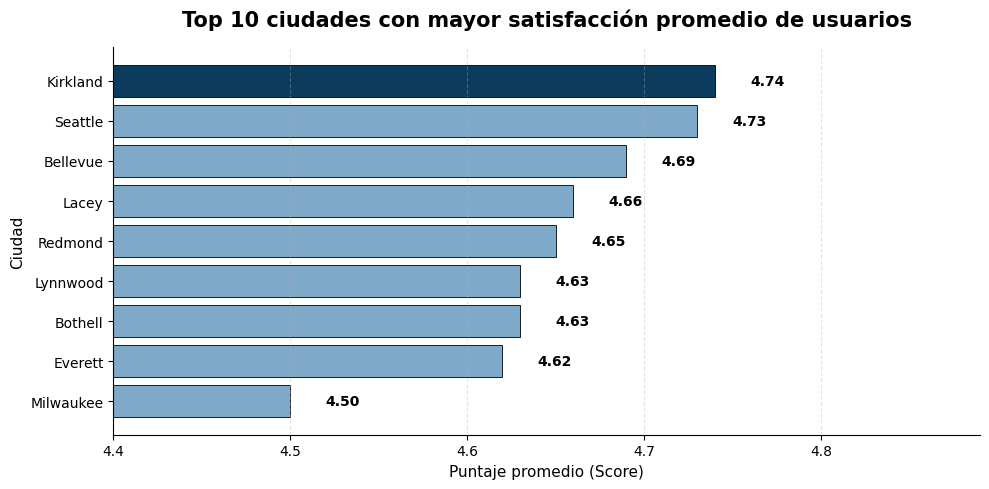

In [37]:
plt.figure(figsize=(10, 5))

# Colores: destacar la ciudad con mayor score
colores = ["#0B3C5D"] + ["#7FA9C9"] * (len(df_ranking_ciudades)-1)

barras = plt.barh(
    df_ranking_ciudades["ciudad"],
    df_ranking_ciudades["score_promedio"],
    color=colores,
    edgecolor="black",
    linewidth=0.6
)

# Mayor score arriba
plt.gca().invert_yaxis()


# Etiquetas de valores
for barra in barras:
    valor = barra.get_width()

    plt.text(
        valor + 0.02,
        barra.get_y() + barra.get_height()/2,
        f"{valor:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )


# Título
plt.title(
    "Top 10 ciudades con mayor satisfacción promedio de usuarios",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Puntaje promedio (Score)",
    fontsize=11
)

plt.ylabel(
    "Ciudad",
    fontsize=11
)


# Escala del eje X
plt.xlim(
    df_ranking_ciudades["score_promedio"].min() - 0.1,
    df_ranking_ciudades["score_promedio"].max() + 0.15
)


# Cuadrícula
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)


# Eliminar bordes superiores y derechos
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()

plt.show()